In [26]:
import os
import pandas as pd
import numpy as np
import joblib

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [27]:
# Load saved training data (now includes upazila)
X_train = np.load("../models/X_train.npy")
X_test = np.load("../models/X_test.npy")
y_train = np.load("../models/y_train.npy")
y_test = np.load("../models/y_test.npy")
target_encoder = joblib.load("../models/target_encoder.pkl")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("# Features (includes upazila):", X_train.shape[1])

X_train shape: (12000, 21)
X_test shape: (3000, 21)
# Features (includes upazila): 21


In [28]:
# Reshape for LSTM (samples, timesteps, features)
# Note: upazila is now included in the features
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)

X_train_lstm shape: (12000, 1, 21)
X_test_lstm shape: (3000, 1, 21)


In [29]:
# Improved LSTM architecture for better performance
model = Sequential()

model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(1, X_train_lstm.shape[2])
    )
)
model.add(Dropout(0.2))

model.add(
    LSTM(
        64,
        return_sequences=False
    )
)
model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(3, activation="softmax"))

import tensorflow as tf
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
# Early stopping to prevent overfitting
callbacks = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train_lstm,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7530 - loss: 0.5655 - val_accuracy: 0.5113 - val_loss: 0.8656
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8321 - loss: 0.3946 - val_accuracy: 0.6942 - val_loss: 0.6444
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8435 - loss: 0.3597 - val_accuracy: 0.8288 - val_loss: 0.4253
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8470 - loss: 0.3502 - val_accuracy: 0.8717 - val_loss: 0.3010
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8483 - loss: 0.3377 - val_accuracy: 0.8733 - val_loss: 0.2787
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8562 - loss: 0.3285 - val_accuracy: 0.8683 - val_loss: 0.2897
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8575 - loss: 0.3227 - val_accuracy: 0.8733 - val_loss: 0.2734
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8558 - loss: 0.3206 - val_accuracy: 0.

In [31]:
pred = model.predict(X_test_lstm)
lstm_pred = np.argmax(pred, axis=1)

acc = accuracy_score(y_test, lstm_pred)
print("LSTM Accuracy:", acc)
print(classification_report(y_test, lstm_pred, target_names=target_encoder.classes_))

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM Accuracy: 0.888
              precision    recall  f1-score   support

        High       0.88      0.81      0.85       798
         Low       0.94      0.92      0.93       716
      Medium       0.87      0.91      0.89      1486

    accuracy                           0.89      3000
   macro avg       0.90      0.88      0.89      3000
weighted avg       0.89      0.89      0.89      3000



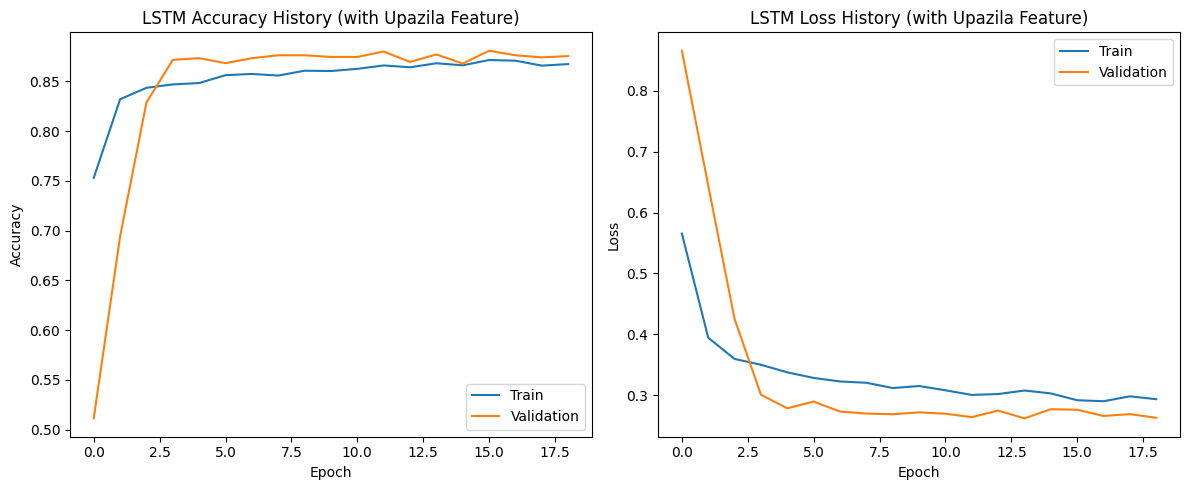

In [32]:
# Plot accuracy and loss history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("LSTM Accuracy History (with Upazila Feature)")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("LSTM Loss History (with Upazila Feature)")

plt.tight_layout()
plt.show()

In [33]:
os.makedirs("../models", exist_ok=True)
model.save("../models/lstm_model.keras")
print("LSTM model saved with upazila feature!")

LSTM model saved with upazila feature!
